# Neuro-Genomic AI — Data Sources

This notebook uses data from three external databases, ingested via `src/train_from_physionet.py` and stored in the local SQLite database at `data/processed/neuro_genomic.db`.

## 1. Separated Components (Fetal / Maternal ECG)
Physiological ECG signals used for signal separation and HRV feature extraction.

| Database | Description | PhysioNet URL |
|---|---|---|
| **nifecgdb** | Non-Invasive Fetal ECG Database | https://physionet.org/content/nifecgdb/ |
| **ltdb** (`longecgdb`) | MIT Long-Term ECG Database | https://physionet.org/content/ltdb/ |
| **adfecgdb** (`adecg`) | Abdominal and Direct Fetal ECG Database | https://physionet.org/content/adfecgdb/ |

## 2. Behavioral Data
Cognitive load and stress task recordings (EEG, ECG, EDA signals per task window).

| Database | Description | URL |
|---|---|---|
| **CLAS** (PhysioNet) | Cognitive Load, Affect and Stress Recognition Dataset | https://physionet.org/content/clas/1.0.0/ |

## 3. Genomic Data
Phenotype and genomic study data from EGA (European Genome-phenotype Archive).

| Study ID | Description | URL |
|---|---|---|
| **phs000500** | EGA Study (dbGaP accession) | https://ega-archive.org/studies/phs000500 |

---
> Run `python src/train_from_physionet.py` first to populate the database from all three sources before executing cells below.

In [8]:
# Load data from local SQLite database (populated by src/train_from_physionet.py)
#
# Data sources:
#   Separated components (physio_data):
#     - nifecgdb  -> https://physionet.org/content/nifecgdb/
#     - ltdb      -> https://physionet.org/content/ltdb/
#     - adfecgdb  -> https://physionet.org/content/adfecgdb/
#   Behavioral data (behavioral_data):
#     - PhysioNet CLAS -> https://physionet.org/content/clas/1.0.0/
#   Genomic data (genomic_data):
#     - EGA phs000500 -> https://ega-archive.org/studies/phs000500
#
# To populate the DB run:
#   python src/train_from_physionet.py

from pathlib import Path
import sqlite3
import pandas as pd
import sys

base_data = Path('../data')
db_path = base_data / 'processed' / 'neuro_genomic.db'
db_path.parent.mkdir(parents=True, exist_ok=True)

if not db_path.exists():
    sys.path.insert(0, str(Path('..') / 'src'))
    try:
        import numpy as np
        from data_pipeline import DataPipeline
        pipeline = DataPipeline(data_dir=base_data, db_path=db_path)

        # Separated components: try nifecgdb, adfecgdb, ltdb in order
        for db_name in ('nifecgdb', 'adfecgdb', 'ltdb'):
            try:
                import wfdb
                records = wfdb.get_record_list(db_name)
                if records:
                    pipeline.ingest_physionet_record_to_database(
                        database=db_name, record_name=records[0],
                        table_name='physio_data', db_path=db_path, if_exists='replace',
                    )
                    print(f'  Ingested physio from {db_name}/{records[0]}')
                    break
            except Exception as e:
                print(f'  Skipped {db_name}: {e}')

        # Behavioral: PhysioNet CLAS - https://physionet.org/content/clas/1.0.0/
        try:
            behavioral_df = pipeline.download_behavioral_physionet(
                database='clas', record_name='001', db_path=db_path,
                table_name='behavioral_data', if_exists='replace',
            )
            print(f'  Ingested behavioral data: {behavioral_df.shape}')
        except Exception as e:
            print(f'  CLAS download failed ({e}). Using synthetic fallback.')
            n = 20
            behavioral_df = pd.DataFrame({
                'task_id': range(n), 'click_rate': [4.0]*n,
                'typing_speed': [35.0]*n, 'error_rate': [0.12]*n, 'focus_score': [0.65]*n,
            })
            pipeline.store_dataframe_in_database(behavioral_df, 'behavioral_data', db_path=db_path)

        # Genomic: EGA phs000500 - https://ega-archive.org/studies/phs000500
        try:
            genomic_df = pipeline.download_genomic_ega(
                study_id='phs000500', db_path=db_path,
                table_name='genomic_data', if_exists='replace',
            )
            print(f'  Ingested genomic data: {genomic_df.shape}')
        except Exception as e:
            print(f'  EGA download failed ({e}). Using synthetic fallback.')
            n = 20
            genomic_df = pd.DataFrame({
                'sample_id': range(n), 'gene_expression_a': [0.6]*n,
                'gene_expression_b': [0.4]*n, 'study_id': ['phs000500']*n,
            })
            pipeline.store_dataframe_in_database(genomic_df, 'genomic_data', db_path=db_path)

    except Exception as exc:
        raise RuntimeError(
            f'Database not found at {db_path} and auto-ingestion failed: {exc}\n'
            'Run: python src/train_from_physionet.py'
        )

# Load all three tables
with sqlite3.connect(db_path) as conn:
    physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)
    genomic_data = pd.read_sql_query('SELECT * FROM genomic_data', conn)
    behavioral_data = pd.read_sql_query('SELECT * FROM behavioral_data', conn)

print('Loaded from database:')
print(f'  physio (separated components): {physio_data.shape}')
print(f'  genomic (EGA phs000500):       {genomic_data.shape}')
print(f'  behavioral (PhysioNet CLAS):   {behavioral_data.shape}')
physio_data.head()

Loaded from database:
  physio (separated components): (10828800, 9)
  genomic (EGA phs000500):       (10828, 5)
  behavioral (PhysioNet CLAS):   (10828, 5)


,sample_index,time_sec,ECG1,ECG2,record_name,database,sampling_rate,source_database,source_record
0,0,0.000000,0.16,-0.29,14046,ltdb,128.0,ltdb,14046
1,1,0.007812,0.18,-0.30,14046,ltdb,128.0,ltdb,14046
2,2,0.015625,0.17,-0.32,14046,ltdb,128.0,ltdb,14046
3,3,0.023438,0.18,-0.29,14046,ltdb,128.0,ltdb,14046
4,4,0.031250,0.18,-0.31,14046,ltdb,128.0,ltdb,14046


In [9]:
# Physio variable setup and validation
# This cell guarantees physio_data exists and defines feature columns based on schema.
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

# Preferred columns for old synthetic schema
legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
legacy_available = [c for c in legacy_cols if c in physio_data.columns]

if legacy_available:
    physio_feature_cols = legacy_available
else:
    # MIT-BIH schema fallback: use numeric ECG channels
    excluded = {'sample_index', 'time_sec', 'sampling_rate'}
    physio_feature_cols = [
        c for c in physio_data.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
    ]

if not physio_feature_cols:
    raise ValueError('No usable physiological feature columns were found in physio_data.')

print(f'physio_data shape: {physio_data.shape}')
print('physio_data columns:', list(physio_data.columns))
print('physio_feature_cols:', physio_feature_cols)
physio_data.head(3)

physio_data shape: (10828800, 9)
physio_data columns: ['sample_index', 'time_sec', 'ECG1', 'ECG2', 'record_name', 'database', 'sampling_rate', 'source_database', 'source_record']
physio_feature_cols: ['ECG1', 'ECG2']


,sample_index,time_sec,ECG1,ECG2,record_name,database,sampling_rate,source_database,source_record
0,0,0.000000,0.16,-0.29,14046,ltdb,128.0,ltdb,14046
1,1,0.007812,0.18,-0.30,14046,ltdb,128.0,ltdb,14046
2,2,0.015625,0.17,-0.32,14046,ltdb,128.0,ltdb,14046


In [10]:
# Define and validate physiological feature columns used in analysis cells
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

if not physio_feature_cols:
    raise ValueError('No usable physiological feature columns found for analysis.')

print('physio_data variable is ready.')
print('Available columns:', list(physio_data.columns))
print('Analysis feature columns:', physio_feature_cols)
print('Shape:', physio_data.shape)

physio_data variable is ready.
Available columns: ['sample_index', 'time_sec', 'ECG1', 'ECG2', 'record_name', 'database', 'sampling_rate', 'source_database', 'source_record']
Analysis feature columns: ['ECG1', 'ECG2']
Shape: (10828800, 9)


Correlation Matrix:
       ECG1   ECG2
ECG1  1.000 -0.176
ECG2 -0.176  1.000


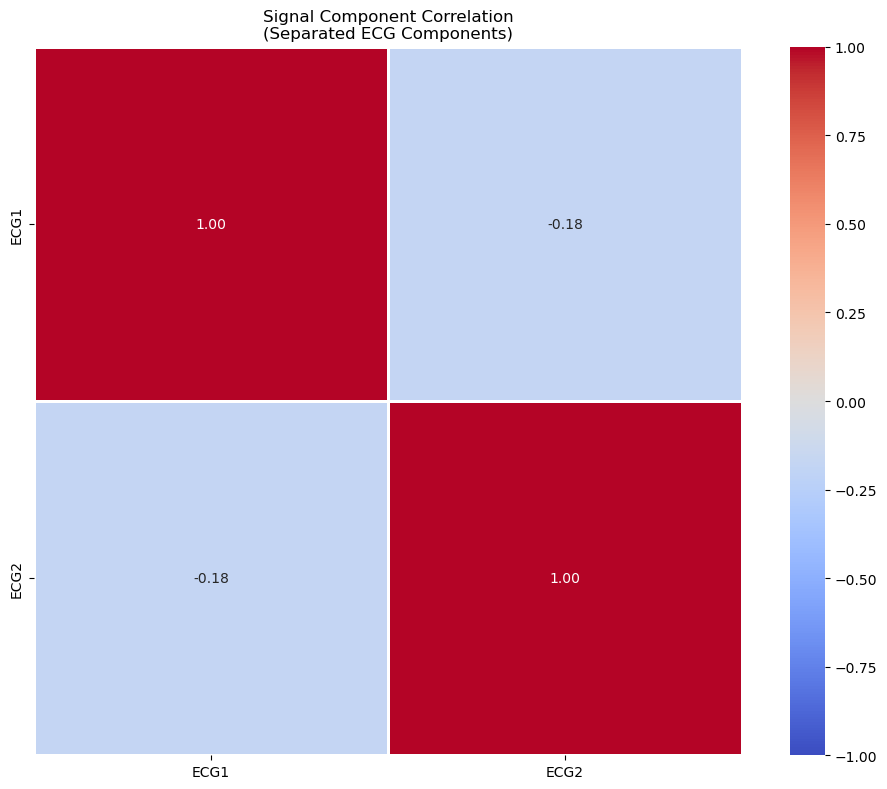

✅ Correlation heatmap saved to ..\results\plots\correlation_heatmap.png


In [11]:
# Correlation analysis
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-load DB tables if this cell is run before the data-loading cell
if 'physio_data' not in globals():
    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM separated_components', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    excluded = {'sample_index', 'time_sec', 'sampling_rate', 'time_s'}
    physio_feature_cols = [
        c for c in physio_data.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
    ]

correlation_matrix = physio_data[physio_feature_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

plots_dir = Path('../results/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Signal Component Correlation\n(Separated ECG Components)')
plt.tight_layout()
plt.savefig(plots_dir / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Correlation heatmap saved to {plots_dir / 'correlation_heatmap.png'}")

In [12]:
# Descriptive statistics
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

print(physio_data[physio_feature_cols].describe().round(2))

for col in physio_feature_cols:
    data = physio_data[col]
    print(f"\n{col}: skew={data.skew():.3f}  kurtosis={data.kurtosis():.3f}")

              ECG1         ECG2
count  10828800.00  10828800.00
mean         -0.01        -0.02
std           0.34         0.91
min          -4.74        -5.12
25%          -0.04        -0.30
50%           0.01        -0.19
75%           0.07        -0.09
max           5.11         5.11

ECG1: skew=0.946  kurtosis=35.955

ECG2: skew=4.053  kurtosis=18.510


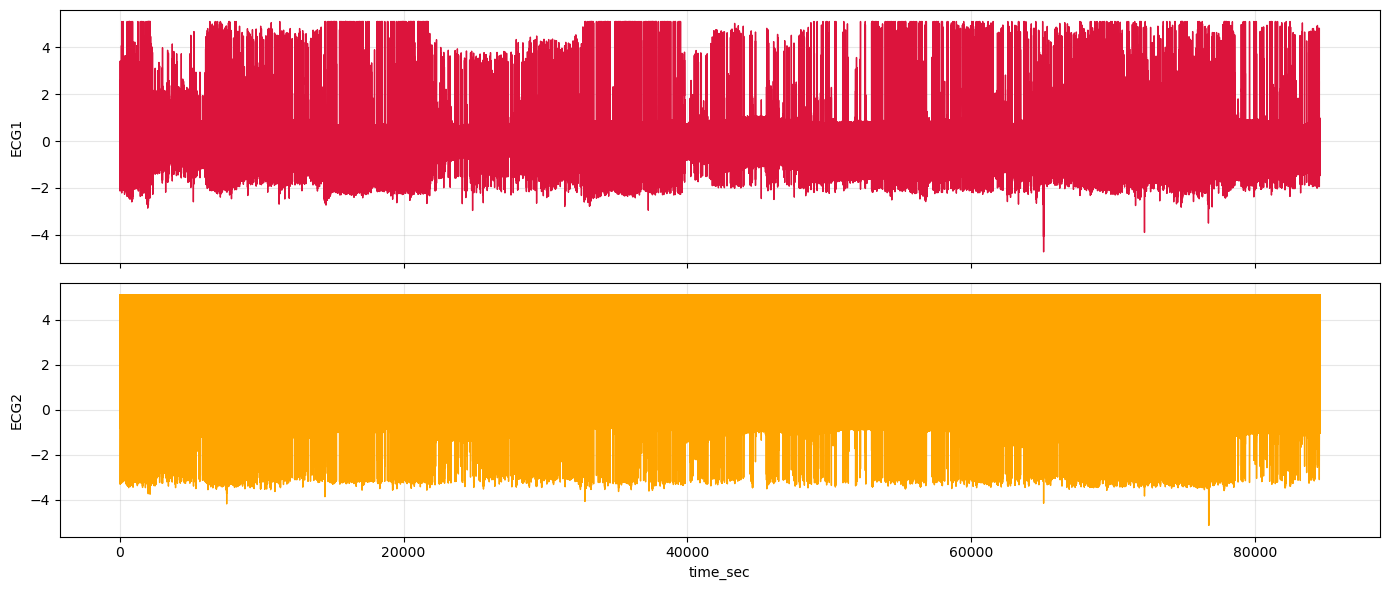

In [13]:
# Plot physiological signals
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd
    import matplotlib.pyplot as plt

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

x_col = 'timestamp' if 'timestamp' in physio_data.columns else ('time_sec' if 'time_sec' in physio_data.columns else 'sample_index')

fig, axes = plt.subplots(len(physio_feature_cols), 1, figsize=(14, 3 * len(physio_feature_cols)), sharex=True)
if len(physio_feature_cols) == 1:
    axes = [axes]

palette = ['crimson', 'orange', 'green', 'purple', 'blue', 'teal', 'brown', 'magenta']
for i, (ax, col) in enumerate(zip(axes, physio_feature_cols)):
    ax.plot(physio_data[x_col], physio_data[col], linewidth=1, color=palette[i % len(palette)])
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(x_col)

plots_dir = Path('../results/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(plots_dir / 'physiological_signals.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Quick preview of loaded database tables
if not {'physio_data', 'genomic_data', 'behavioral_data'}.issubset(globals()):
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)
        genomic_data = pd.read_sql_query('SELECT * FROM genomic_data', conn)
        behavioral_data = pd.read_sql_query('SELECT * FROM behavioral_data', conn)

print('Physio columns:', list(physio_data.columns))
print('Genomic columns:', list(genomic_data.columns))
print('Behavioral columns:', list(behavioral_data.columns))

print('\nPhysio sample:')
print(physio_data.head(3))

print('\nGenomic sample:')
print(genomic_data.head(3))

print('\nBehavioral sample:')
print(behavioral_data.head(3))

Physio columns: ['sample_index', 'time_sec', 'ECG1', 'ECG2', 'record_name', 'database', 'sampling_rate', 'source_database', 'source_record']
Genomic columns: ['sample_id', 'gene_expression_a', 'gene_expression_b', 'gene_expression_c', 'variant_load']
Behavioral columns: ['task_id', 'click_rate', 'typing_speed', 'error_rate', 'focus_score']

Physio sample:
   sample_index  time_sec  ECG1  ECG2 record_name database  sampling_rate  \
0             0  0.000000  0.16 -0.29       14046     ltdb          128.0   
1             1  0.007812  0.18 -0.30       14046     ltdb          128.0   
2             2  0.015625  0.17 -0.32       14046     ltdb          128.0   

  source_database source_record  
0            ltdb         14046  
1            ltdb         14046  
2            ltdb         14046  

Genomic sample:
   sample_id  gene_expression_a  gene_expression_b  gene_expression_c  \
0          0           0.674507           0.333665           0.468160   
1          1           0.579260   

In [15]:
# Imports for plotting style
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
print('Libraries imported.')

Libraries imported.


In [16]:
# Verify dependencies
packages = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'scipy', 'plotly']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  {pkg}: installed')
    except ImportError:
        print(f'  {pkg}: MISSING')

  numpy: installed
  pandas: installed
  sklearn: installed
  matplotlib: installed
  seaborn: installed
  scipy: installed
  plotly: installed


In [17]:
# Create project directory structure
from pathlib import Path

structure = {
    'data': ['physio', 'genomic', 'behavioral'],
    'notebooks': [],
    'src': [],
    'diagrams': [],
    'docs': [],
    'results': ['plots', 'models']
}

base_path = Path('.')
for main_dir, subdirs in structure.items():
    (base_path / main_dir).mkdir(exist_ok=True)
    for subdir in subdirs:
        (base_path / main_dir / subdir).mkdir(exist_ok=True)

print('Project structure created.')

Project structure created.
